# Moral Signaling ABM

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from MoralABM import MoralABM

In [2]:
import pandas as pd

In [3]:
import time

## Moral Foundations Empirical Priors

In [4]:
mf_priors = pd.read_csv('./priors/mf_priors.csv')
# mf_priors = mf_priors.assign(
#     resp_mean = mf_priors.resp.apply(lambda x: np.mean([int(item) for item in x if item not in [' ']]))
# )
mf_priors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128640 entries, 0 to 128639
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   id        128640 non-null  int64  
 1   bin_pol   128640 non-null  object 
 2   grad_pol  128640 non-null  object 
 3   mf        128640 non-null  object 
 4   a         128640 non-null  float64
 5   b         128640 non-null  float64
 6   resp      128640 non-null  object 
 7   resp_m    128640 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 7.9+ MB


In [5]:
foundations = ['care', 'fairness', 'ingroup', 'authority', 'purity']

In [6]:
# Get moral foundations priors (Beta)
conservative_betas = mf_priors[mf_priors.bin_pol=='conservative'].groupby('id').apply(
    lambda x : np.array([list(x[x.mf==mf].a) + list(x[x.mf==mf].b)
                for mf in foundations]).flatten()
)

liberal_betas = mf_priors[mf_priors.bin_pol=='liberal'].groupby('id').apply(
    lambda x : np.array([list(x[x.mf==mf].a) + list(x[x.mf==mf].b)
                for mf in foundations]).flatten()
)

/var/folders/cg/49fv39xs0w7b42v0thstyfvw0000gq/T/ipykernel_44135/1928007622.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conservative_betas = mf_priors[mf_priors.bin_pol=='conservative'].groupby('id').apply(
/var/folders/cg/49fv39xs0w7b42v0thstyfvw0000gq/T/ipykernel_44135/1928007622.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  liberal_betas = mf_priors[mf_priors.bin_pol=='liberal'].groupby('id

In [7]:
liberal_dirichlet = mf_priors[mf_priors.bin_pol=='liberal'].groupby('id').apply(
    lambda x : [list(x[x.mf==mf].resp_m)[0]+1 
                for mf in foundations]
)

conservative_dirichlet = mf_priors[mf_priors.bin_pol=='conservative'].groupby('id').apply(
    lambda x : [list(x[x.mf==mf].resp_m)[0]+1 
                for mf in foundations]
)

/var/folders/cg/49fv39xs0w7b42v0thstyfvw0000gq/T/ipykernel_44135/2517299991.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  liberal_dirichlet = mf_priors[mf_priors.bin_pol=='liberal'].groupby('id').apply(
/var/folders/cg/49fv39xs0w7b42v0thstyfvw0000gq/T/ipykernel_44135/2517299991.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conservative_dirichlet = mf_priors[mf_priors.bin_pol=='conservative'].gro

In [8]:
conservative_priors = conservative_betas
liberal_priors = liberal_betas

#### Quick check for timing

In [9]:
n_steps = 100
agent_samples = np.arange(10)
times = np.zeros(len(agent_samples))
for i,n_agents in enumerate(agent_samples):
    t = time.time()
    abm = MoralABM(n_agents=n_agents,n_steps=n_steps,beta_prior=True,priors=[conservative_priors,liberal_priors])
    times[i] = time.time()-t
    print(f'Time for {n_agents} agents: {times[i]}')

Time for 0 agents: 0.0001049041748046875
Time for 1 agents: 0.02091193199157715
Time for 2 agents: 0.048538923263549805
Time for 3 agents: 0.10306882858276367
Time for 4 agents: 0.18485403060913086
Time for 5 agents: 0.3049910068511963
Time for 6 agents: 0.4109537601470947
Time for 7 agents: 0.6040029525756836
Time for 8 agents: 0.7776718139648438
Time for 9 agents: 0.9649839401245117


## Simulation
Run ABM simulation with desired number of agents and time steps 

For each time step we can get a a graph representation of the network by the adjacency matrix

In [10]:
n_agents = 30
n_steps = 1000

In [11]:
t = time.time()
abm = MoralABM(n_agents = n_agents, n_steps = n_steps, priors = [conservative_priors,liberal_priors],beta_prior=True,normalize=False)
print(f'Time elapsed: {time.time()-t}')

Time elapsed: 103.78894901275635


In [20]:
AMs = abm.mf_graph
Belief_AMs = abm.belief_graph
# AMs = [abm.get_adjacency_matrix(step) for step in range(n_steps) if step%10 ==0]
# Belief_AMs = [abm.get_adjacency_matrix(step,belief=True) for step in range(n_steps) if step%10 ==0]

## Visualizations

### Moral representations over time
An agents representation over time

In [21]:
# for beta parameters
def beta_means(rep):
    return np.array([rep[i]/(rep[i]+rep[i+1]) for i in 2*np.arange(5)])

# for dirichlet parameters
def normalize_representation(rep):
    return rep/sum(rep)

In [22]:
def plot_representation(agent):
    plt.plot(
        np.array([beta_means(x) for i,x in enumerate(abm.M_agents[agent,agent,:10,:].T) if i%1==0]),
        label = foundations
    )
    # plt.ylim([0,1])
    plt.legend()
    plt.title(f"Agent {agent}'s moral values over time")
    # plt.show()

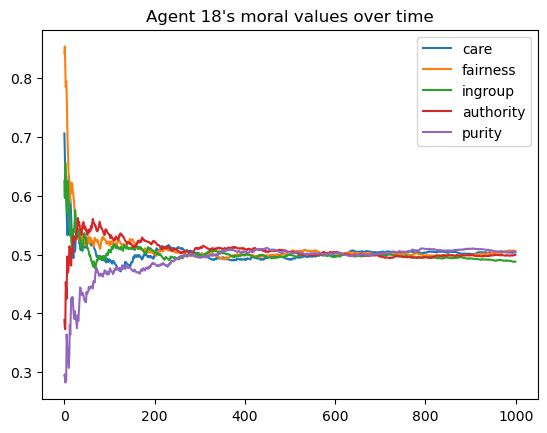

In [23]:
agent = np.random.randint(n_agents) # pick a random agent to look at
plot_representation(agent)

In [24]:
cons_agents = [i for i in range(n_agents) if i < n_agents// 2]
lib_agents = [i for i in range(n_agents) if i >= n_agents// 2]

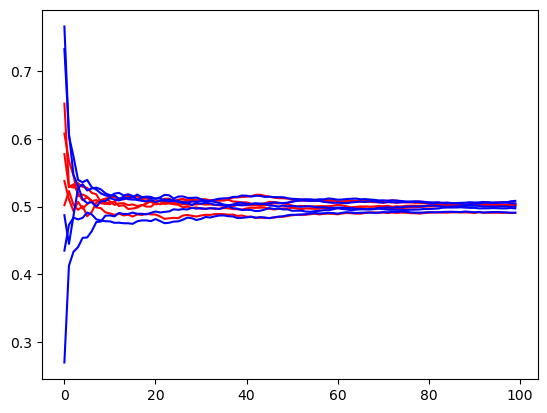

In [25]:
plt.plot(
    np.mean(
        [beta_means(x) for idx,x in enumerate(abm.M_agents[cons_agents,cons_agents,:10,:].T) if idx%10==0],axis=2
        ),
    color='r'
)

plt.plot(
    np.mean(
        [beta_means(x) for idx,x in enumerate(abm.M_agents[lib_agents,lib_agents,:10,:].T) if idx%10==0],axis=2
        ),
    color='b'
)

In [26]:
normed_AMs = np.exp(-np.array(AMs))
normed_beliefs = np.exp(-np.array(Belief_AMs))

(array([18.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  2.,  0.,  1.,  0.,  0.,
         0.,  0.,  0.,  7.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  3.,  0.,
        40.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  6.,  0.,  0.,  0., 18.,  0.,  0.,  3.]),
 array([ 2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,  5.5,  6. ,  6.5,  7. ,
         7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5, 11. , 11.5, 12. , 12.5,
        13. , 13.5, 14. , 14.5, 15. , 15.5, 16. , 16.5, 17. , 17.5, 18. ,
        18.5, 19. , 19.5, 20. , 20.5, 21. , 21.5, 22. , 22.5, 23. , 23.5,
        24. , 24.5, 25. , 25.5, 26. , 26.5, 27. ]),
 <BarContainer object of 50 artists>)

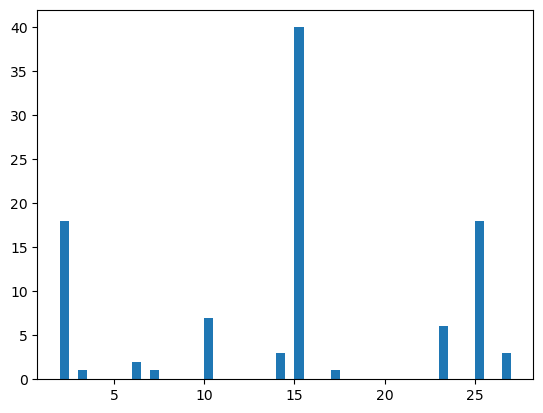

In [27]:
# Histogram of the most influencial agents over time
plt.hist(
    [normed_beliefs[i].sum(axis=0).argmax() for i in range(n_steps//10)],
    bins=50
)

In [28]:
def simplify_graph(AM,outgoing=True,diag_fill = 1):
    if outgoing:
        new_AM = np.triu(AM)+np.tril(AM.T)
    else:
        new_AM = np.tril(AM)+np.triu(AM.T)
    np.fill_diagonal(new_AM,diag_fill)
    return new_AM

## Finding Global Clusters

### Spectral Clustering

In [29]:
import networkx as nx
from sklearn.cluster import SpectralClustering

In [30]:
initial_groups = [i >= n_agents//2 for i in range(n_agents)]

/opt/homebrew/Caskroom/miniconda/base/envs/pgm/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:310: UserWarning: Array is not symmetric, and will be converted to symmetric by average with its transpose.
  adjacency = check_symmetric(adjacency)


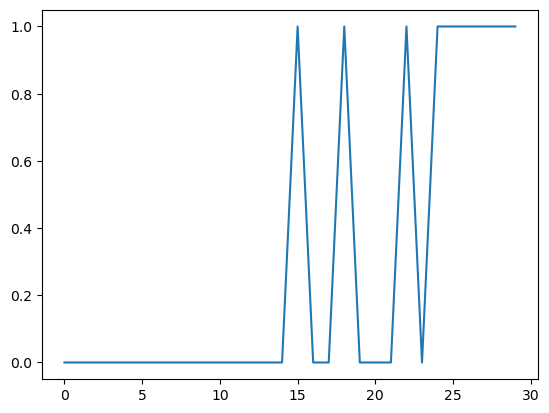

In [31]:
sc = SpectralClustering(2,affinity='precomputed')
sc.fit(normed_AMs[2])

plt.plot(sc.labels_)

/opt/homebrew/Caskroom/miniconda/base/envs/pgm/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:310: UserWarning: Array is not symmetric, and will be converted to symmetric by average with its transpose.
  adjacency = check_symmetric(adjacency)


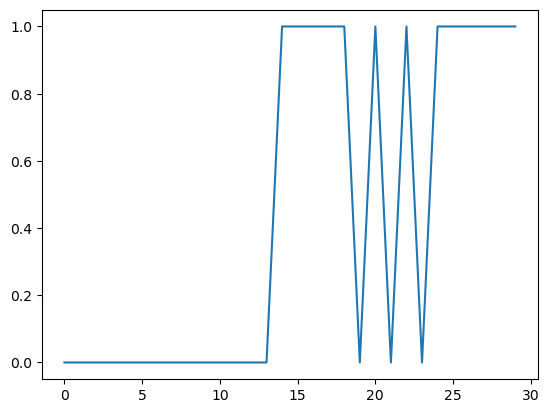

In [32]:
sc = SpectralClustering(2,affinity='precomputed')
sc.fit(normed_AMs[1])
plt.plot(sc.labels_)

In [33]:
def remove_self_loops(G):
    """Removes edges from nodes to themselves in a graph."""
    G.remove_edges_from(nx.selfloop_edges(G))
    return G

def color_nodes(G):
    """Colors the first half of nodes red and the second half blue."""
    num_nodes = len(G.nodes)
    colors = ['red'] * (num_nodes // 2) + ['blue'] * (num_nodes - num_nodes // 2) 
    return colors

def draw_graph(G):
    """Draws the graph with specified modifications."""
    G = remove_self_loops(G)
    colors = color_nodes(G)
    pos = nx.spring_layout(G, weight='weight') 
    # pos = nx.spectral_layout(G,
    #                          weight='weight',
    #                         )

    # Adjust visual parameters
    node_size = 50  # Adjust as needed
    width = 0.10  # Adjust as needed

    nx.draw(G, 
            pos, 
            node_color=colors, 
            node_size=node_size, 
            width=width)
    plt.show()

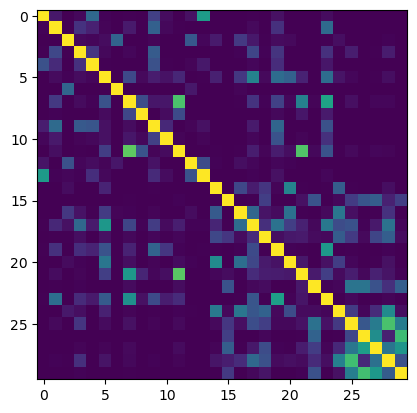

In [36]:
plt.imshow(normed_AMs[2])

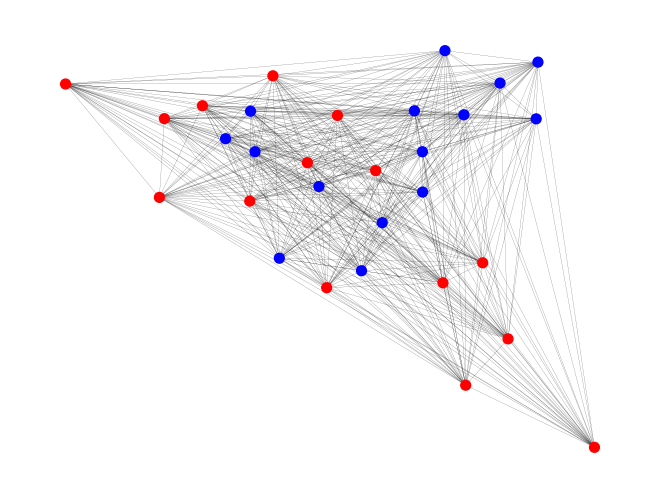

In [37]:
G = nx.from_numpy_array(simplify_graph(normed_AMs[2],False))
draw_graph(G)

### DBSCAN

In [198]:
from sklearn.cluster import DBSCAN

In [483]:
# Run DBSCAN
db = DBSCAN(eps=0.5, min_samples=2, metric='precomputed') 
labels = db.fit(1-simplify_graph(normed_AMs[-10]))

# Analyze the results
print("Cluster labels:", db.labels_)

Cluster labels: [ 0  1  2  3 -1  0 -1  4  0  2  5 -1  0  0  0  0  0 -1  1  2 -1 -1  0  0
  0  0  6  0  0  4  0  0  0 -1 -1  5  7  0  0  0  0  0  8  6  0  0  0  0
  0  6  7  0  0  0 -1  0  0  6  6 -1 -1  0  9 -1 -1  0 10 -1 -1  1  0  6
 -1  7 -1  0 -1  0  9  8  0 -1 -1  3  0 -1  0 -1 -1  0 10 -1  0  0  0  5
  0  0 -1  7]


### Linkage

In [112]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [113]:
AM = (1-normed_AMs[-1])
G = nx.from_numpy_array(AM)
dist_AM = nx.floyd_warshall_numpy(G, weight='weight')

# Perform hierarchical clustering using single linkage
Z = linkage(dist_AM, method='ward')
# Z = linkage(dist_AM, method='ward')

clusters = fcluster(Z, 2, criterion='maxclust')
unique_clusters = np.unique(clusters)
cluster_counts = {cluster_id: np.where(clusters == cluster_id)[0] for cluster_id in unique_clusters}

/var/folders/cg/49fv39xs0w7b42v0thstyfvw0000gq/T/ipykernel_40182/864636978.py:6: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dist_AM, method='ward')


ValueError: The condensed distance matrix must contain only finite values.

In [553]:
cluster_counts[1]

array([ 0,  8, 15, 23, 27, 30, 44, 46, 48, 51, 52, 55, 56, 67, 74, 80, 92,
       93, 94, 97])

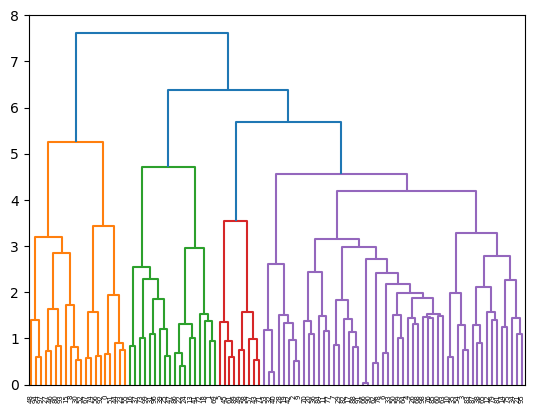

In [555]:
# Visualize the dendrogram
d = dendrogram(Z)

In [557]:
d.keys()

dict_keys(['icoord', 'dcoord', 'ivl', 'leaves', 'color_list', 'leaves_color_list'])

In [566]:
[key for key in d.keys() if len(d[key])==100]

['ivl', 'leaves', 'leaves_color_list']

In [493]:
G = nx.from_numpy_array(1-simplify_graph(normed_AMs[10],diag_fill=1))
dist_G = nx.floyd_warshall_numpy(G, weight='weight')

## Local clustering coefficient

Cluster coefficient by agent

In [91]:
def get_agent_cluster_coefficients(AM):
    return nx.clustering(
        nx.from_numpy_array(AM,
                            create_using=nx.DiGraph),
        weight='weight') 

In [92]:
belief_clusters = [get_agent_cluster_coefficients(am) for i,am in enumerate(normed_beliefs) if i%10==0]
actual_clusters = [get_agent_cluster_coefficients(am) for i,am in enumerate(normed_AMs) if i%10==0]

NameError: name 'nx' is not defined

In [270]:
belief_df = pd.DataFrame(belief_clusters).T
actual_df = pd.DataFrame(actual_clusters).T

In [273]:
cons_beliefs = belief_df[0:50]
lib_beliefs = belief_df[50:]

<Axes: >

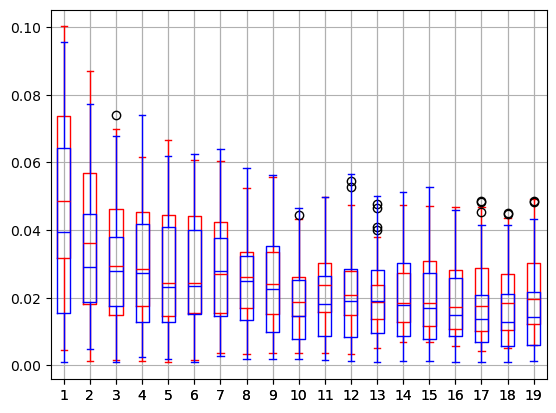

In [287]:
cons_beliefs.T[1:].T.boxplot(color='red')
lib_beliefs.T[1:].T.boxplot(color='blue')

<Axes: >

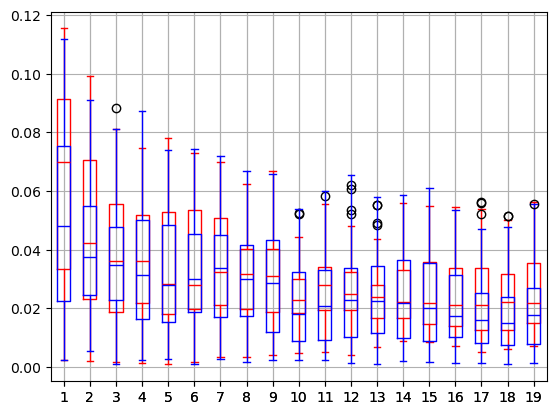

In [292]:
actual_df[:50].T[1:].T.boxplot(color='red')
actual_df[50:].T[1:].T.boxplot(color='blue')

In [ ]:
cons_beliefs.T[1:].T.boxplot(color='red')
lib_beliefs.T[1:].T.boxplot(color='blue')

In [206]:
colors = ['r' if group else 'b' for group in [i < n_agents//2 for i in range(n_agents)]]

<Axes: >

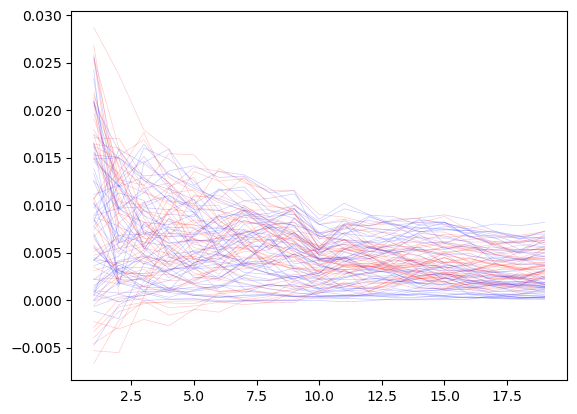

In [298]:
estimation_diff = (actual_df.T-belief_df.T)
estimation_diff[1:].plot(
    color = colors, 
    legend=False,
    lw = 0.5,
    alpha =0.2
)

## Save network GIF


In [ ]:
import imageio

In [ ]:
def create_gif(matrices, filename='animation.gif', fps=10):
    """
    Creates a GIF animation from a list of matrices.

    Args:
        matrices: A list of numpy arrays representing the matrices.
        filename: The filename for the output GIF.
        fps: Frames per second for the animation.
    """

    images = []
    for matrix in matrices:
        plt.figure()
        plt.imshow(matrix, cmap='viridis', interpolation='nearest')
        plt.axis('off')
        plt.savefig('temp.png')
        images.append(imageio.imread('temp.png'))
        plt.close()

    imageio.mimsave(filename, images, fps=fps)


In [ ]:
create_gif(AMs,'mfs-n100-priors-1.gif')

In [ ]:
create_gif(Belief_AMs,'beliefs-n100-priors-1.gif')